**Worl Cup 2026 Player Performance Dataset Analysis**

1. **DATA CLEANING**
 Importa Important Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df= pd.read_csv("World_cup_2026.csv")

 Show the top 5 rows

In [4]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left


   Check the number of columns and rows

In [12]:
df.shape

(1248, 10)

   Check missing values in the DataFrame

In [5]:
df.isnull().sum()

player_id         0
player_name       0
age               0
nationality       0
team              0
jersey_number     0
position          0
height_cm         0
weight_kg         0
preferred_foot    0
dtype: int64

  Remove duplicates (inplace=True means applies changes directly to dataframe itself, without making a copy)

 Check duplicates

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
54595     True
54596     True
54597     True
54598     True
54599     True
Length: 54600, dtype: bool

 Understanding the results of df.duplicated()

It checks each row in your DataFrame and returns a Boolean Series (True or False).

False → the row is not a duplicate (it’s the first time that exact row appears).

True → the row is a duplicate of a previous row.

The first few rows (0–4) are marked False → they are unique rows.

The last rows (54595–54599) are marked True → they are duplicates of earlier rows in the dataset.

The total length (54600) matches your DataFrame’s number of rows, meaning every row has been checked.

In [10]:
df.drop_duplicates(inplace=True)

 Checking duplicates after dropping them

In [4]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
54595     True
54596     True
54597     True
54598     True
54599     True
Length: 54600, dtype: bool

**No more duplicates, they are all dropped**

2.Define Features and Target-Import Pandas**

In [7]:
X = df[['age','height_cm','weight_kg','preferred_foot','nationality','team','jersey_number']]
y = df['position']

3. **Encode Categorical Variables**

In [9]:
# Encode target
from sklearn.preprocessing import LabelEncoder   # encoding target
import pandas as pd   # for one-hot encoding

y = LabelEncoder().fit_transform(y)

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['nationality','team'], drop_first=True)

# Encode preferred_foot as binary
X['preferred_foot'] = X['preferred_foot'].map({'Left':0, 'Right':1})

4. **Feature Selection → scikit-learn**

**Use ANOVA F-test (SelectKBest) to pick the most relevant features**.

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif   # feature selection

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['age', 'height_cm', 'weight_kg', 'preferred_foot', 'jersey_number'], dtype='object')


5.**Train-Test Split**

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

**6.Scale Numerical Features**

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**7.Train Model**

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**8.Evaluate Model**

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[3828    0    0    0]
 [   0 2479    0    0]
 [   0    0 1266    0]
 [   0    0    0 3347]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3828
           1       1.00      1.00      1.00      2479
           2       1.00      1.00      1.00      1266
           3       1.00      1.00      1.00      3347

    accuracy                           1.00     10920
   macro avg       1.00      1.00      1.00     10920
weighted avg       1.00      1.00      1.00     10920



**Results Interpretation**
  
**Accuracy**
  
**Accuracy: 1.0 → This means the model predicted every single sample correctly**

**Out of 10,920 test samples, all were classified into the right category.**

**In plain words: the model achieved 100% accuracy.**

**Steps to Plot a Confusion Matrix Heatmap**

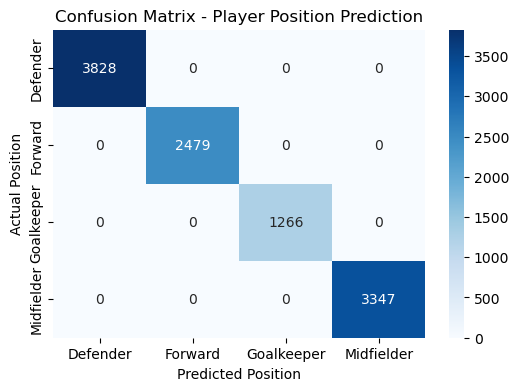

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LabelEncoder().fit(df['position']).classes_,
            yticklabels=LabelEncoder().fit(df['position']).classes_)
plt.xlabel("Predicted Position")
plt.ylabel("Actual Position")
plt.title("Confusion Matrix - Player Position Prediction")
plt.show()


In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Recreate the encoder used for y
encoder = LabelEncoder()
encoder.fit(df['position'])

# Build comparison table
comparison = pd.DataFrame({
    # Instead of using y_test.index, we just take the first N player IDs
    "Player_ID": df["player_id"].iloc[:len(y_test)].values,
    "Actual_Position": encoder.inverse_transform(y_test),
    "Predicted_Position": encoder.inverse_transform(y_pred)
})

# Show first 10 rows
print(comparison.head(10))

  Player_ID Actual_Position Predicted_Position
0    P00055        Defender           Defender
1    P00070      Midfielder         Midfielder
2    P00066      Midfielder         Midfielder
3    P00073      Goalkeeper         Goalkeeper
4    P00059         Forward            Forward
5    P00072         Forward            Forward
6    P00058      Midfielder         Midfielder
7    P00078         Forward            Forward
8    P00056      Midfielder         Midfielder
9    P00074         Forward            Forward


**import pandas as pd**
**from sklearn.preprocessing import LabelEncoder**
**This brings in two tools:**

**pandas → helps us work with tables of data.**

**LabelEncoder → helps us turn words (like “Goalkeeper”, “Midfielder”) into numbers so the computer can compare them.**

**Recreate the encoder used for y encoder = LabelEncoder()**
**encoder.fit(df['position'])**
**Here we:**

**Create a “translator” called encoder.**

**Teach it the list of all positions in your dataset (df['position']).**

**Now it knows how to switch between words (like “Forward”) and numbers (like 2).**

**Build comparison table**
**comparison = pd.DataFrame({"Player_ID": df.loc[y_test.index, "player_id"].values,"Actual_Position": encoder.inverse_transform(y_test),"Predicted_Position": encoder.inverse_transform(y_pred)})**

**This builds a new table called comparison:**

**Player_ID → pulls the player’s ID from the dataset.**

**Actual_Position → shows the real position from the dataset (the “official team sheet”).**

**Predicted_Position → shows what the model guessed (the “coach’s prediction”)**.

**inverse_transform means we turn the numbers back into words so you see “Goalkeeper” instead of 0.**


**Saving as CSV**

In [24]:
df.to_csv("WorldCup2026_cleaned.csv", index=False)


**Save the trained model**

In [25]:
import joblib
joblib.dump(model, "player_position_model.pkl")

['player_position_model.pkl']